In [ ]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

result_names = [
    # "results_2025-09-10_15-37-47_gpt2-medium",
    # "results_2025-08-28_13-41-37_gpt2-xl",
    # "causal_trace_gpt2-xl_2025-11-07_08-47-06",
    "causal_trace_Qwen-Qwen3-0.6B_2025-11-07_10-59-19",
    # "causal_trace_ibm-granite-granite-4.0-micro_2025-11-07_17-39-16"
    # "causal_trace_Qwen-Qwen3-8B_2025-11-17_12-20-46"
    # "causal_trace_Qwen-Qwen3-4B_2025-11-18_09-38-51"
]

for filename in result_names:
    df = pd.read_csv(f"{filename}.csv")

    display(df)

    df['clean'] = df['clean'].apply(ast.literal_eval)
    df['corrupted'] = df['corrupted'].apply(ast.literal_eval)
    df['restored'] = df['restored'].apply(ast.literal_eval)


    num_of_layers = len(df['restored'][0])

    df_expanded = df['restored'].apply(pd.Series)

    df_final = pd.concat([df.drop('restored', axis=1), df_expanded], axis=1)
    df_final["clean_token"] = df_final["clean"].apply(lambda x: x[0])
    df_final["clean"] = df_final["clean"].apply(lambda x: x[1])

    df_ff = df_final
    df_ff["corrupted"] = df_ff["corrupted"].apply(lambda x: x[1])
    
    for i in range(num_of_layers):
        df_ff[i] = df_ff[i].apply(lambda x: x[1])
        df_ff[i] = df_ff[i] - df_ff["corrupted"]

    df_preproc = df_ff
    try:
        df_preproc = df_preproc.drop('prompt_num', axis=1)
    except:
        ...
    df_preproc = df_preproc.drop('clean', axis=1)
    df_preproc = df_preproc.drop('corrupted', axis=1)
    df_p_g = df_preproc.groupby(["run_number"]).max(["restored_token"]).drop("restored_token", axis=1)

    display(df_p_g)

    sns.barplot(data=df_p_g, errorbar=None)
    plt.show()


In [ ]:
from reimagined.utils import load_pretrained
from omegaconf import DictConfig

cfg = DictConfig({
    "model": {
        "name": "Qwen/Qwen3-0.6B",
        "models_dir": "./models",
        "second_moment_dir": "./second_moment_stats",
        "device": "cuda",
        "save_to_local": True, # Keep this True until you specifically do not want the model cached locally
        "layer_name_template": "model.layers.{}.mlp.down_proj",
        "layer": 5,
        "corruption_noise_multiplier": 0.287875235080719,
    }
})

# cfg = DictConfig({
#     "model": {
#         "name": "gpt2-large",
#         "models_dir": "./models",
#         "second_moment_dir": "./second_moment_stats",
#         "device": "cpu",
#         "save_to_local": True, # Keep this True until you specifically do not want the model cached locally
#         "layer_name_template": "model.layers.{}.mlp.down_proj",
#         "layer": 5,
#         "corruption_noise_multiplier": 0.287875235080719,
#     }
# })
model, tok = load_pretrained(cfg)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

pcs = []
pcs_mean = []
pcs_std = []
pcs_max = []
pcs_min = []
# for layer in model.model.layers:
for layer in model.transformer.h:
    # sim_matrix = cosine_similarity(layer.mlp.down_proj.weight.detach().numpy())
    sim_matrix = cosine_similarity(layer.mlp.c_proj.weight.detach().numpy())
    pcs.append(sim_matrix)
    pcs_mean.append(sim_matrix.mean())
    pcs_std.append(sim_matrix.std())
    pcs_max.append(sim_matrix.max())
    pcs_min.append(sim_matrix.min())

print(pcs_mean)
print(pcs_std)
print(np.max(pcs_mean))
print(np.min(pcs_mean))
print(np.max(pcs_std))
print(np.min(pcs_std))
print(pcs_max)
print(pcs_min)

# similarity_matrix0 = cosine_similarity(W0)
# similarity_matrix1 = cosine_similarity(W1)
# print("Pair-wise Cosine Similarity Matrix0 mean:\n", similarity_matrix0.mean())
# print("Pair-wise Cosine Similarity Matrix1 mean:\n", similarity_matrix1.mean())
# print("Pair-wise Cosine Similarity Matrix0 STD:\n", similarity_matrix0.std())
# print("Pair-wise Cosine Similarity Matrix1 STD:\n", similarity_matrix1.std())

In [ ]:
import torch

# new_W = torch.load("pcs_gpt2-large_12.pt", map_location=torch.device('cpu'))
# sim_matrix = cosine_similarity(new_W.detach().numpy())

# new_W_nopcs = torch.load("new_weights/gpt2-xl_18.pt", map_location=torch.device('cpu'))
# sim_matrix_nopcs = cosine_similarity(new_W_nopcs.detach().numpy())

new_W_nopcs = torch.load("failed_Qwen-Qwen3-0.6B_10.pt", map_location=torch.device('cpu'))
# sim_matrix_nopcs = cosine_similarity(new_W_nopcs.detach().numpy())

sim_m = pcs[5]



In [ ]:

new_W_nopcs

In [ ]:
model_new.transformer.h[12].mlp.c_proj.weight

In [ ]:
diag = torch.diag(model_new.transformer.h[12].mlp.c_proj.weight @ new_W_nopcs.T)
diag.max()

In [ ]:
print((model_new.transformer.h[12].mlp.c_proj.weight - new_W_nopcs).min())
print((model_new.transformer.h[12].mlp.c_proj.weight - new_W_nopcs).max())

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def analyze_vector_lengths(vector_lengths):
    """
    Plots vector lengths with outliers highlighted and prints outlier info.
    
    Args:
        vector_lengths (torch.Tensor or np.ndarray): 1D tensor/array of vector lengths.
    """
    # Convert to NumPy if necessary
    if isinstance(vector_lengths, torch.Tensor):
        lengths_np = vector_lengths.numpy()
    else:
        lengths_np = vector_lengths

    # --- Detect outliers using IQR ---
    Q1 = np.percentile(lengths_np, 25)
    Q3 = np.percentile(lengths_np, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = lengths_np[(lengths_np < lower_bound) | (lengths_np > upper_bound)]

    # Print outlier info
    print(f"Number of outliers: {len(outliers)}")
    print(f"Outlier values: {outliers}")

    # --- Boxplot ---
    plt.figure(figsize=(10, 5))
    plt.boxplot(lengths_np, vert=True, patch_artist=True, showfliers=True)
    plt.ylabel("Vector Length")
    plt.title("Boxplot of Vector Lengths with Outliers")
    plt.show()

    # --- Scatter plot with outliers highlighted ---
    plt.figure(figsize=(10, 5))
    plt.scatter(range(len(lengths_np)), lengths_np, label="Data Points")
    outlier_indices = np.where((lengths_np < lower_bound) | (lengths_np > upper_bound))[0]
    plt.scatter(outlier_indices, outliers, color='red', label='Outliers', zorder=5)
    plt.ylabel("Vector Length")
    plt.xlabel("Index")
    plt.title("Vector Lengths with Outliers Highlighted")
    plt.legend()
    plt.show()


# --- Example usage ---
vector_lengths = ((model_new.transformer.h[12].mlp.c_proj.weight) - new_W_nopcs).norm(dim=1).detach().to("cpu")  # sample data
analyze_vector_lengths(vector_lengths)


In [ ]:
row_norms = torch.norm(new_W_nopcs, p=2, dim=1, keepdim=True)
A_normalized = new_W_nopcs / row_norms

row_norms = torch.norm(model_new.transformer.h[12].mlp.c_proj.weight, p=2, dim=1, keepdim=True)
B_normalized = model_new.transformer.h[12].mlp.c_proj.weight / row_norms

vector_lengths = (A_normalized - B_normalized).norm(dim=1).detach().to("cpu")  # sample data
analyze_vector_lengths(vector_lengths)

In [ ]:
# print(sim_matrix.mean())
# print(sim_matrix.std())

print("")

print("NOPCS:")
print(sim_matrix_nopcs.mean())
print(sim_matrix_nopcs.std())

print("")
print("ORIGINAL")
print(sim_m.mean())
print(sim_m.std())

print("")

# print(f"PCS: {sim_matrix.sum()/((sim_matrix.shape[0]*sim_matrix.shape[1])**2 - (sim_matrix.shape[0]*sim_matrix.shape[1]))}")
print(f"NOPCS: {sim_matrix_nopcs.sum()/((sim_matrix_nopcs.shape[0]*sim_matrix_nopcs.shape[1])**2 - (sim_matrix_nopcs.shape[0]*sim_matrix_nopcs.shape[1]))}")
print(f"ORIG: {sim_m.sum()/((sim_m.shape[0]*sim_m.shape[1])**2 - (sim_m.shape[0]*sim_m.shape[1]))}")


# print("")

# print(sim_matrix.max())
# print(sim_matrix.min())

# print(sim_matrix.flatten().shape)


In [ ]:
prompt = tok("The Eiffel Tower is in", return_tensors="pt")["input_ids"]
output = model.generate(prompt)
print(tok.batch_decode(output))

prompt = tok("The Eiffel Tower is located in", return_tensors="pt")["input_ids"]
output = model.generate(prompt, do_sample=False)
print(tok.batch_decode(output))

In [ ]:
model_new, _ = load_pretrained(cfg)

In [ ]:
new_W_nopcs.dtype

In [ ]:
# model_new.transformer.h[12].mlp.c_proj.weight = torch.nn.Parameter(new_W_nopcs)
model_new.model.layers[10].mlp.down_proj.weight = torch.nn.Parameter(new_W_nopcs.to(torch.float))
prompt = tok("The Eiffel Tower is in", return_tensors="pt")["input_ids"]
output = model_new.generate(prompt)
print(tok.batch_decode(output))

prompt = tok("The symbol of French Revolution, the Eiffel Tower, is", return_tensors="pt")["input_ids"]
output = model_new.generate(prompt)
print(tok.batch_decode(output))

In [ ]:
from reimagined.utils import load_dataset
from omegaconf import DictConfig

cfg = DictConfig({
    "dataset": {
        "name":"wikimedia/wikipedia",
        "datasets_dir":"./datasets",
        "save_to_local":True
    }
})
ds = load_dataset(cfg)

In [ ]:
ds

# ROME analysis

In [119]:
from reimagined.utils import load_pretrained
from omegaconf import DictConfig

cfg = DictConfig({
    "model": {
        "name": "Qwen/Qwen3-0.6B",
        "models_dir": "./models",
        "device": "cpu",
        "save_to_local": True, # Keep this True until you specifically do not want the model cached locally
        "layer_name_template": "model.layers.{}.mlp.down_proj",
        "layer": 9,
    }
})

model, tok = load_pretrained(cfg)
orig_W = model.model.layers[cfg.model.layer].mlp.down_proj.weight.detach()
new_W = torch.load("Qwen-Qwen3-0.6B_9_P103_0.pt", map_location=torch.device('cpu')).detach()

In [126]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def analyze_vector_lengths(vector_lengths, title, filename):
    """
    Plots vector lengths with outliers highlighted and prints outlier info.
    
    Args:
        vector_lengths (torch.Tensor or np.ndarray): 1D tensor/array of vector lengths.
    """
    # Convert to NumPy if necessary
    if isinstance(vector_lengths, torch.Tensor):
        lengths_np = vector_lengths.numpy()
    else:
        lengths_np = vector_lengths

    # --- Detect outliers using IQR ---
    Q1 = np.percentile(lengths_np, 25)
    Q3 = np.percentile(lengths_np, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = lengths_np[(lengths_np < lower_bound) | (lengths_np > upper_bound)]

    # Print outlier info
    print(f"Number of outliers: {len(outliers)}")
    print(f"Outlier values: {outliers}")

    # # --- Boxplot ---
    # plt.figure(figsize=(10, 5))
    # plt.boxplot(lengths_np, vert=True, patch_artist=True, showfliers=True)
    # plt.ylabel("Vector Length")
    # plt.title("Boxplot of Vector Lengths with Outliers")
    # plt.show()

    # --- Scatter plot with outliers highlighted ---
    plt.figure(figsize=(10, 5))
    plt.scatter(range(len(lengths_np)), lengths_np, label="Data Points")
    outlier_indices = np.where((lengths_np < lower_bound) | (lengths_np > upper_bound))[0]
    plt.scatter(outlier_indices, outliers, color='red', label='Outliers', zorder=5)
    plt.ylabel(title)
    plt.xlabel("Index")
    plt.title(f"{title} with Outliers Highlighted")
    plt.legend()
    plt.savefig(f"./figs/{filename}.png")


Number of outliers: 34
Outlier values: [0.0026902  0.01831052 0.0165426  0.03354298 0.00706282 0.00462229
 0.02367054 0.03430048 0.02502129 0.01185234 0.00471364 0.02265844
 0.39711198 0.0328672  0.02119295 0.01921042 0.01256998 0.02961796
 0.02490465 0.0047836  0.01253292 0.01215506 0.01809304 0.01140745
 0.0020409  0.00873962 0.01571825 0.01319972 0.02076364 0.41494244
 0.02031281 0.0190472  0.02425446 0.00484287]


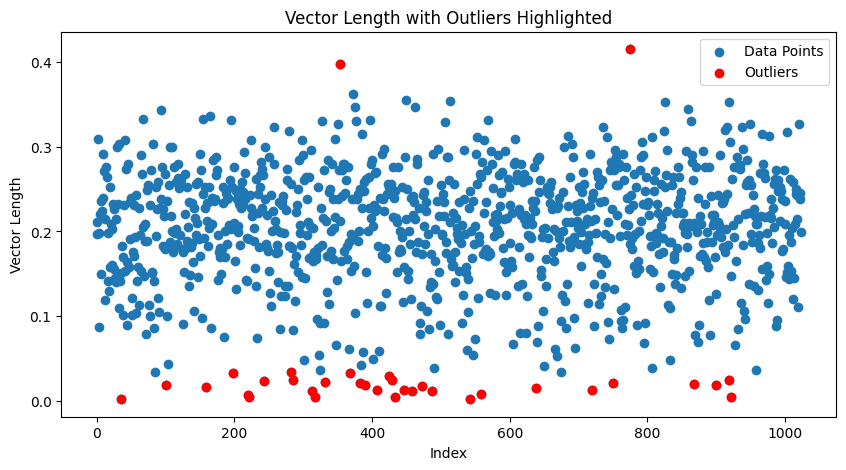

In [128]:
# --- Example usage ---
vector_lengths = (orig_W - new_W).norm(dim=1)  # sample data
analyze_vector_lengths(vector_lengths, "Vector Length", "test")

Number of outliers: 67
Outlier values: [0.32053468 0.2981891  0.29697633 0.35125998 0.00289176 0.31000087
 0.32029217 0.38638383 0.3647103  0.38013837 0.40321177 0.35369495
 0.33139414 0.3399957  0.32882392 0.3694492  0.29392692 0.3807984
 0.33474714 0.33554584 0.30174035 0.31127498 0.29787618 0.3127596
 0.34568936 0.32553437 0.35062543 0.34136793 0.40208033 0.32060593
 0.3591108  0.30373245 0.34738433 0.29658148 0.38356778 0.33086422
 0.38001117 0.37038806 0.3314796  0.32351285 0.34822866 0.39068812
 0.01060699 0.00485501 0.33697248 0.29589036 0.29691505 0.38244778
 0.31650743 0.32124007 0.29904994 0.3597287  0.3307031  0.00824906
 0.00436908 0.00875263 0.00375353 0.00908204 0.00881268 0.01348865
 0.00831693 0.0028716  0.0061761  0.01146002 0.00929527 0.29507488
 0.00383077]


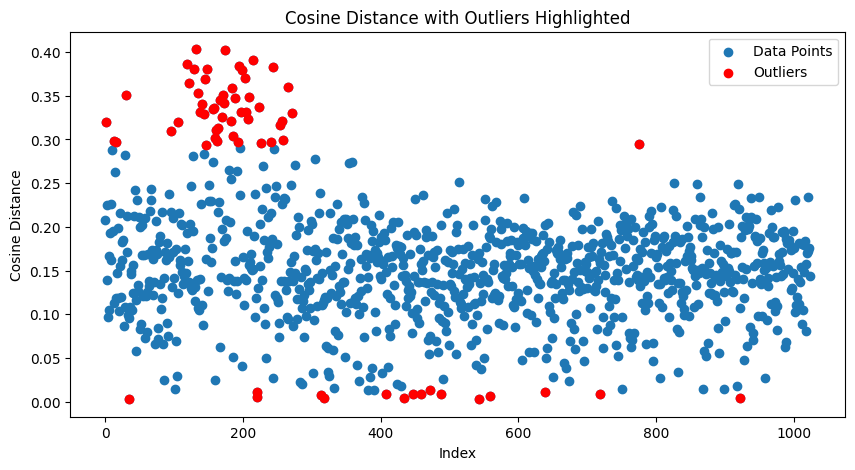

In [125]:
row_norms = torch.norm(new_W, p=2, dim=1, keepdim=True)
A_normalized = new_W / row_norms

row_norms = torch.norm(orig_W, p=2, dim=1, keepdim=True)
B_normalized = orig_W / row_norms

vector_lengths = (A_normalized - B_normalized).norm(dim=1).detach().to("cpu")  # sample data
analyze_vector_lengths(vector_lengths, "Cosine Distance")